# Task 1: House Price Prediction using Linear Regression

## Artificial Intelligence & Machine Learning Internship

### Objective
The objective of this project is to build and evaluate a Linear Regression model using the California Housing dataset. The project includes data loading, exploratory data analysis (EDA), model training, evaluation, and visualization of results.

## 1. Import Required Libraries

In this section, we import all the libraries required for data analysis, visualization, machine learning, and model evaluation.

In [1]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import dataset
from sklearn.datasets import fetch_california_housing

# Import train-test split
from sklearn.model_selection import train_test_split

# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Matplotlib is building the font cache; this may take a moment.


## 2. Load the California Housing Dataset

The California Housing dataset is provided by Scikit-learn. It contains information about houses in California such as median income, house age, average rooms, population, latitude, longitude, and median house value.

In [3]:
# Load California Housing dataset
housing = fetch_california_housing(as_frame=True)

# Combine features and target into a single DataFrame
df = pd.concat(
    [housing.data, housing.target.rename("HousePrice")],
    axis=1
)

# Display first five rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Exploratory Data Analysis (EDA)

EDA helps us understand the structure of the dataset before building the machine learning model.

Dataset Shape: (20640, 9)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


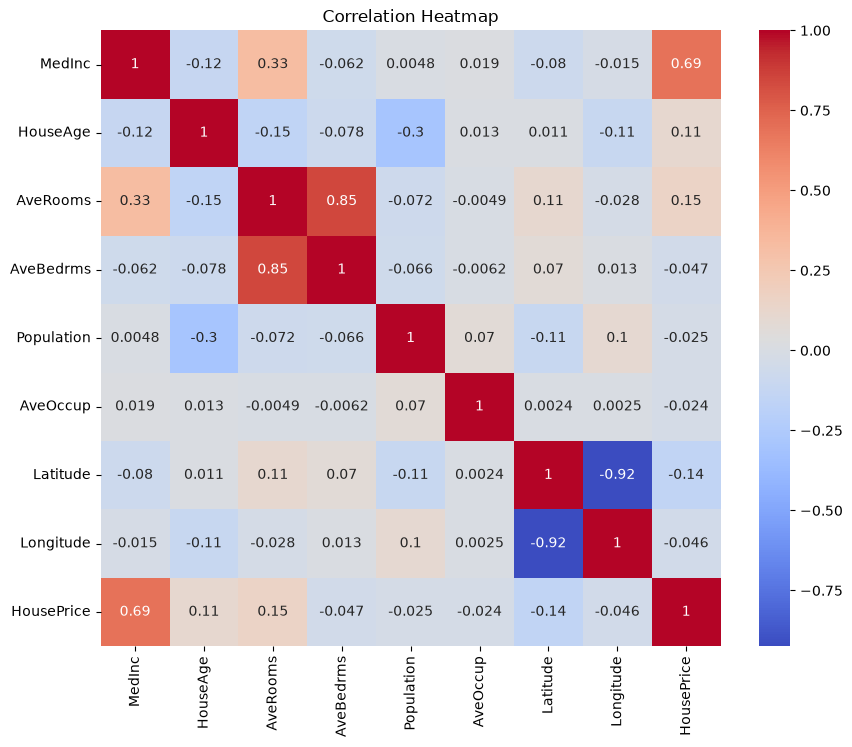

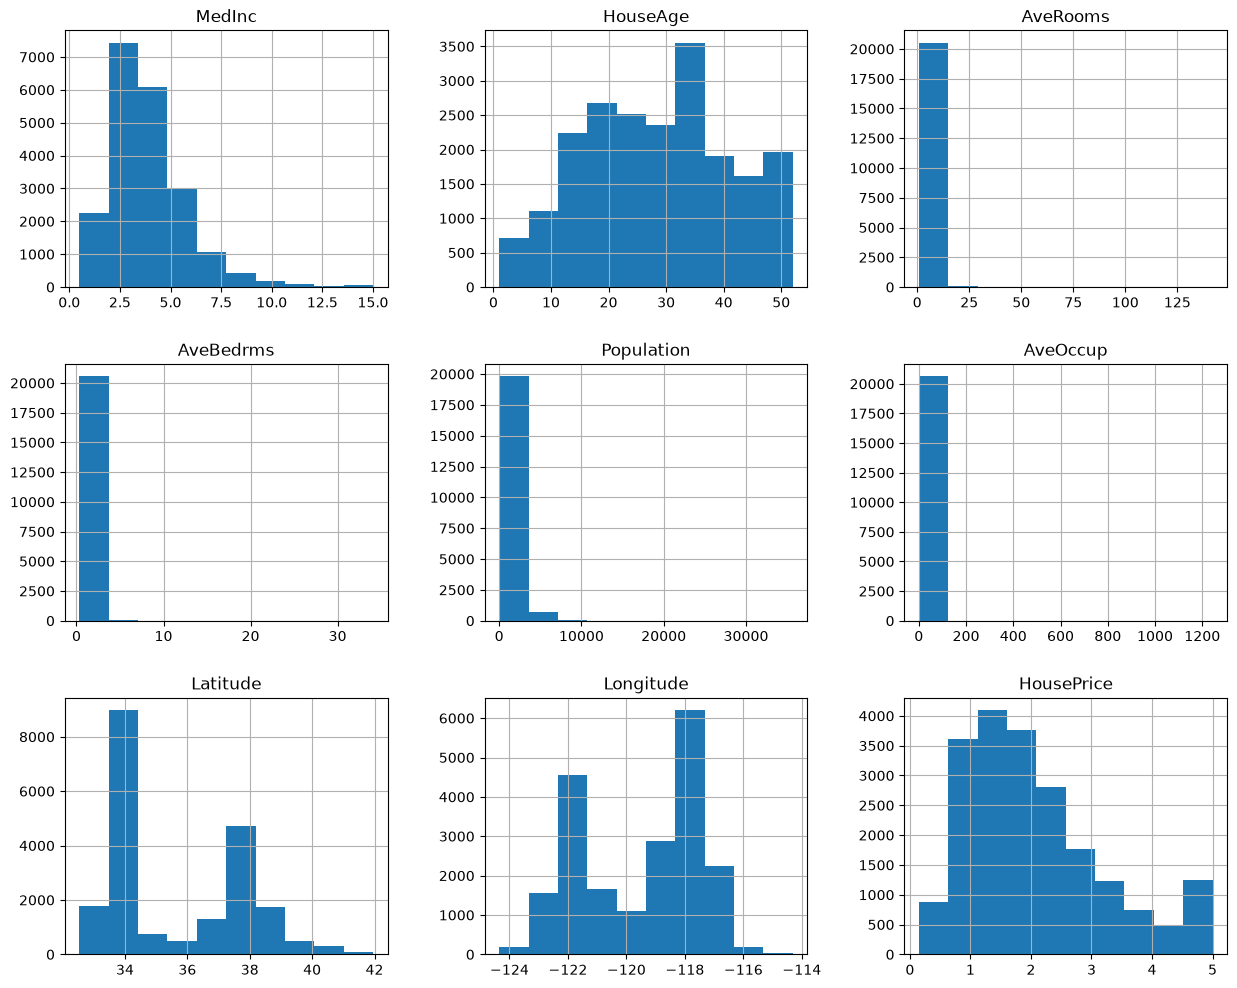

In [4]:
# Display number of rows and columns
print("Dataset Shape:", df.shape)
# Display dataset information
df.info()
# Display statistical summary
df.describe()
# Check for missing values
df.isnull().sum()

# Plot correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Plot histograms of all features
df.hist(figsize=(15,12))
plt.show()

## 4. Data Preparation

Separate the dataset into input features (X) and target variable (y).

In [5]:
# Separate features and target variable
X = df.drop("HousePrice", axis=1)

y = df["HousePrice"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (20640, 8)
Target Shape: (20640,)


## 5. Split the Dataset

Split the dataset into training data (80%) and testing data (20%).

In [6]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (16512, 8)
Testing Data: (4128, 8)


## 6. Train the Linear Regression Model

Train the Linear Regression model using the training dataset.

In [7]:
# Create Linear Regression model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


## 7. Predict House Prices

Use the trained model to predict house prices for the test dataset.

In [8]:
# Predict house prices
y_pred = model.predict(X_test)

print(y_pred[:10])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


## 8. Model Evaluation

Evaluate the performance of the Linear Regression model using MAE, RMSE, and R² Score.

In [9]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.5332001304956558
Root Mean Squared Error (RMSE): 0.7455813830127761
R² Score: 0.5757877060324511


## 9. Actual vs Predicted Values

This graph compares the actual house prices with the predicted house prices.

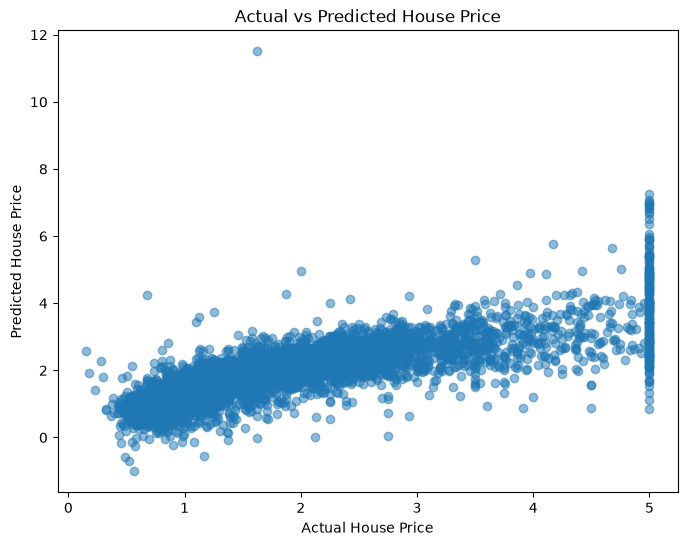

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Price")

plt.show()

## 10. Residual Plot

Residuals represent the difference between actual and predicted values.

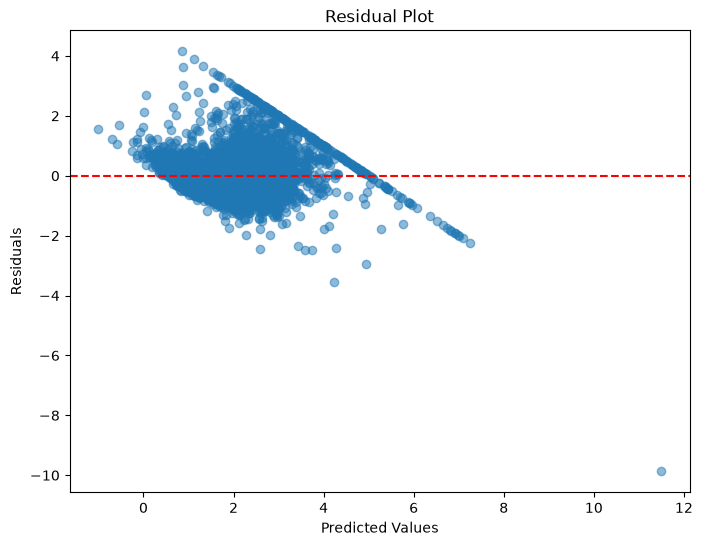

In [11]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

## Feature Importance

In [12]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,MedInc,0.448675
1,HouseAge,0.009724
2,AveRooms,-0.123323
3,AveBedrms,0.783145
4,Population,-0.000002
5,AveOccup,-0.003526
6,Latitude,-0.419792
7,Longitude,-0.433708


## Saving the Trained Model

In [13]:
import pickle

with open("house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully as house_price_model.pkl")

Model saved successfully as house_price_model.pkl


## Conclusion

The Linear Regression model was successfully trained using the California Housing Dataset.

The model achieved good prediction performance using the selected features. Evaluation metrics such as MAE, RMSE and R² Score were used to measure the model's accuracy.

The trained model was also saved as a Pickle (.pkl) file for future predictions.